In [2]:
from langchain_groq import ChatGroq
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image, display

In [ ]:
import os
groq_api_key = os.getenv("GROQ_API_KEY")

In [ ]:
#llm=ChatGroq(groq_api_key='gsk_xxxxxxxxxxxxxx', model_name="llama-3.3-70b-versatile")
llm=ChatGroq(groq_api_key=groq_api_key, model_name="llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x133d649b0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x133df7200>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [53]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    sentiment: str
# 1. Preprocessing Node
def preprocess(state: State) -> State:
    cleaned = state["messages"][-1].content.strip()
    state["messages"][-1].content = cleaned
    return state
# 2. Sentiment Analysis Node
def analyze_sentiment(state: State) -> State:
    msg = state["messages"][-1].content
    state["sentiment"] = "positive" if "good" in msg else "neutral"
    return state
# 3. Chatbot Node
def chatbot(state: State) -> State:
    return {"messages": llm.invoke(state['messages'])}
# 4. Logging Node
def logger(state: State) -> State:
    print(f"LOG: {state['messages'][-1].content}, Sentiment: {state.get('sentiment')}")
    return state

In [54]:
# Build the graph
builder = StateGraph(State)
builder.add_node("preprocess", preprocess)
builder.add_node("analyze_sentiment", analyze_sentiment)  # renamed
builder.add_node("chatbot", chatbot)
builder.add_node("logger", logger)

In [55]:
# Define flow
builder.add_edge(START, "preprocess")
builder.add_edge("preprocess", "analyze_sentiment")  # renamed
builder.add_edge("analyze_sentiment", "chatbot")     # renamed
builder.add_edge("chatbot", "logger")
builder.add_edge("logger", END)

In [56]:
graph = builder.compile()

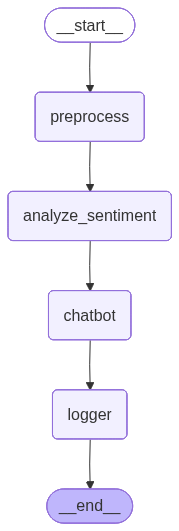

In [57]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [58]:
# Invoke the graph
input_message = "could you talk about quantum computing for non technical learner ? how it will benefit humanity do you think any jobs will created becuase of quntum computing " 
final_state = graph.invoke({"messages": ("user", input_message)})
# Print the final state
print("Final State:", final_state)
print("Chatbot's response:", final_state['messages'][-1].content)
print("Detected Sentiment:", final_state['sentiment'])
input_message_2 = "how impact to ai  "
final_state_2 = graph.invoke({"messages": ("user", input_message_2)})
print("Final State 2:", final_state_2)
print("Chatbot's response 2:", final_state_2['messages'][-1].content)
print("Detected Sentiment 2:", final_state_2['sentiment'])

LOG: I'd be happy to explain quantum computing in a way that's easy to understand, and discuss its potential benefits and job creation.

**What is Quantum Computing?**

Quantum computing is a new way of processing information that's different from the classical computers we use today. Classical computers use "bits" to store and process information, which can only be in one of two states: 0 or 1. Quantum computers, on the other hand, use "qubits" (quantum bits) that can exist in multiple states at the same time, like 0, 1, and both 0 and 1 simultaneously. This property, called superposition, allows quantum computers to process a vast number of possibilities simultaneously, making them incredibly powerful.

**How does it work?**

Imagine you have a combination lock with 10 numbers. A classical computer would try each number one by one, in sequence, to find the correct combination. A quantum computer, however, can try all 10 numbers simultaneously, thanks to superposition. This means that